<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/MonteCarlo_OnPolicy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MonteCarlo On-Policy

*Description*: En este notebook se desarrolla la implementación del método de **Monte Carlo On-Policy (todas las visitas)**, y se emplea sobre los entornos Taxi-v3 y Frozen Lake de Gymnasium.


    Autores: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín

    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
            
    Date: 2026/02/20


Empezamos instalando e importando las librerías necesarias. También definimos los dispositivos donde se ejecutará el notebook y la semilla que vamos a usar para asegurar reproducibilidad.

In [1]:
%%capture
!pip install 'gym[box2d]==0.20.0'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc
import os

In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


gc.collect()              # Ejecuta el recolector de basura de Python
if torch.cuda.is_available():
    torch.cuda.empty_cache()   # Limpia la caché de la GPU


SEED = 123

# NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)

Usando dispositivo: cpu


## Agente


Para implementar los distintos métodos de aprendizaje estudiados en la asignatura, hemos seguido las recomendaciones de Gymnasium para la creación de agentes y la generación de episodios, tal como se indicaba en la definición de la práctica. La idea central ha sido encapsular toda la lógica de interacción y aprendizaje en una clase `Agente`, adaptable a los diferentes algoritmos que se desean evaluar.

En este trabajo nos centramos en **Monte Carlo On-Policy**, en su versión **todas las visitas**. Partimos de la versión proporcionada en el notebook `MonteCarloTodasLasVisitas.ipynb`, que servía como guía inicial, pero que no implementaba completamente la metodología de Monte Carlo. El motivo principal era la forma en que se actualizaban los valores $Q(S,A)$. En Monte Carlo, la actualización de cada par estado-acción debe realizarse al final del episodio usando los retornos específicos desde ese estado, $G_t$, siguiendo la regla:

$$
Q(S_t, A_t) \gets Q(S_t, A_t) + \alpha (G_t - Q(S_t, A_t))
$$

En cambio, en el notebook original se aplicaba la actualización usando el retorno total del episodio $G_0$, lo que rompía la correspondencia entre cada estado-acción y su retorno real, y por tanto no era una verdadera técnica Monte Carlo.

En cuanto a las políticas implementadas, el agente sigue varias políticas. Una **Epsilon-soft** que asigna una mínima probabilidad a todas las acciones, garantizando que nunca se deje de explorar, y una **Epsilon-greedy** que combina explotación de la acción con mayor valor esperado con exploración aleatoria, manteniendo un equilibrio entre ambos objetivos. Además, se usa una política **Greedy** estrictamente explotadora al final del entrenamiento para evaluar la capacidad de aprendizaje del agente.


El aprendizaje se basa en la **iteración de valores Monte Carlo**:

- Los valores $Q(S,A)$ se actualizan al finalizar cada episodio, no durante su ejecución.  
- La versión implementada es **on-policy**, de modo que la política que mejora el agente es la misma que utiliza para explorar.  
- Se aplica el criterio de **todas las visitas**, actualizando el valor de cada par estado-acción cada vez que es visitado dentro de un episodio.  
- La actualización se realiza **en orden inverso**, comenzando por las últimas visitas y avanzando hacia las primeras, siguiendo la metodología descrita por Sutton y Barto.


In [4]:
class MonteCarloOnPolicyAgent:

    def __init__(self, env: gym.Env, epsilon: float, use_decay: bool, gamma: float):
        self.env = env
        self.eps = epsilon
        self.use_decay = use_decay
        self.gamma = gamma

        self.n_actions = env.action_space.n
        self.n_states = env.observation_space.n

        self.q_table = np.zeros((self.n_states, self.n_actions))
        self.n_visits = np.zeros((self.n_states, self.n_actions))
        self.history_returns = {}

    def get_q_values(self):
        return self.q_table

    def log_return(self, state, action, g_value):
        key = (state, action)
        if key not in self.history_returns:
            self.history_returns[key] = []
        self.history_returns[key].append(g_value)

    def get_return(self, state, action):
        return self.history_returns[(state, action)]

    # --- Gestión de Políticas ---

    # Política uniforme
    def get_action_uniform(self, state):
        return np.random.choice(np.arange(self.n_actions))

    def get_uniform_policy(self, state):
        return np.ones(self.n_actions) / self.n_actions

    # Política epsilon-soft. Se usa para el entrenamiento
    def random_epsilon_greedy_policy(self, state):
        pi_A = np.ones(self.n_actions, dtype=float) * self.eps / self.n_actions
        best_action = np.argmax(self.q_table[state])
        pi_A[best_action] += (1.0 - self.eps)
        return pi_A

    # Política epsilon-greedy a partir de una epsilon-soft
    def epsilon_greedy_policy(self, state):
        pi_A = self.random_epsilon_greedy_policy(state)
        return np.random.choice(np.arange(self.n_actions), p=pi_A)

    # Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
    def pi_star_from_Q(self, env):
        done = False
        pi_star = np.zeros([env.observation_space.n, env.action_space.n])
        state, info = env.reset() # start in top-left, = 0
        actions = ""
        while not done:
            action = np.argmax(self.q_table[state, :])
            actions += f"{action}, "
            pi_star[state,action] = action
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        return pi_star, actions


    def update_knowledge(self, episode_data):
        g_return = 0.0

        # Iterar el episodio desde el final hacia el principio
        for s, a, r in reversed(episode_data):
            g_return = r + self.gamma * g_return

            self.n_visits[s,a] = self.n_visits[s,a] + 1

            self.q_table[s, a] += (1.0/self.n_visits[s,a]) * (g_return - self.q_table[s, a])

        return g_return

## Esquema de aprendizaje

Ahora implementamos el proceso de aprendizaje basándonos en el código disponible en el notebook del profesor, cambiando obviamente lo necesario para que la implementación de Monte Carlo sea correcta.

La función `on_policy_all_visit` implementa un aprendizaje Monte Carlo On-Policy considerando todas las visitas de cada episodio. Para cada episodio, el agente genera una trayectoria completa siguiendo su política $\epsilon$-greedy, ajustando $\epsilon$ si se aplica decay, y registra todas las transiciones `(estado, acción, recompensa)`. Al final del episodio, se calculan los retornos y se actualizan los valores de la función de valor de manera incremental. Además, se guarda la longitud de cada episodio y la recompensa acumulada promedio para monitorizar la evolución del aprendizaje y la convergencia de la política.

In [5]:
def on_policy_all_visit(agente, num_episodes=5000):

    # Número de visitas. Vamoa a realizar la versión incremental.
    #n_visits = np.zeros([env.observation_space.n, env.action_space.n])

    # Para mostrar la evolución en el terminal y algún dato que mostrar
    stats = 0.0
    list_stats = []
    step_display = num_episodes / 10

    longitudes = []

    for t in tqdm(range(num_episodes)):
        state, info = agente.env.reset(seed=SEED)
        done = False
        episode = []
        result_sum = 0.0  # Retorno
        while not done:
            if agente.use_decay:
                agente.eps = min(agente.eps, 1000.0/(t+1))

            action = agente.epsilon_greedy_policy(state)
            new_state, reward, terminated, truncated, info = agente.env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = new_state
            result_sum += reward

        g_values = agente.update_knowledge(episode)


        # Guardamos datos sobre la evolución. Promedio de recompensas
        stats += result_sum
        longitudes.append(len(episode))
        list_stats.append(stats/(t+1))


        # Para mostrar la evolución.  Comentar si no se quiere mostrar
        if t % step_display == 0 and t != 0:
            print(f"success: {stats/t}, epsilon: {agente.eps}")

    return longitudes, list_stats

## Funciones auxiliares

Ahora vamos a definir una serie de funciones auxiliares que nos van a servir para mostrar resultados y realizar el análisis.

La primera función que definimos la usaremos una vez entrenado el agente, de forma que podamos evaluar el aprendizaje llevado a cabo.

In [6]:
def capture_optimal_behavior(agente, limit_steps=100):
    """
    Graba un episodio completo siguiendo la política óptima del agente
    y devuelve las métricas de rendimiento junto con los frames de video.
    """
    visual_frames = []
    current_state, _ = agente.env.reset(seed=SEED)

    accumulated_reward = 0.0
    steps_count = 0
    is_finished = False

    while not is_finished and steps_count < limit_steps:
        # 1. Capturar el estado visual actual
        img_frame = agente.env.render()
        visual_frames.append(img_frame)

        # 2. Decidir acción basada en la política objetivo (greedy)
        chosen_action = np.argmax(agente.get_q_values()[current_state, :])

        # 3. Ejecutar transición en el entorno
        next_s, reward, terminated, truncated, _ = agente.env.step(chosen_action)

        # 4. Actualizar contadores y estado
        accumulated_reward += reward
        current_state = next_s
        steps_count += 1
        is_finished = terminated or truncated

    # Capturar el último frame tras el fin del episodio
    visual_frames.append(agente.env.render())
    agente.env.close()

    return accumulated_reward, steps_count, visual_frames

Las siguiente funciones mostrarán las gráficas de aprendizaje y longitud de los episodios una vez realizado el aprendizaje de los agentes.

La longitud del episodio es un medidor de rendimiento interesante porque no solo indica si el agente alcanza la meta, sino también **cómo de eficiente es la política aprendida**. En entornos donde existe una ruta óptima, la convergencia hacia un número estable y bajo de pasos suele reflejar que el agente ha aprendido un comportamiento estructurado y cercano al óptimo.

Además, esta métrica permite interpretar mejor los resultados: episodios muy cortos pueden indicar caídas tempranas en estados terminales negativos, mientras que episodios largos pueden reflejar exploración excesiva o movimientos erráticos. Por ello, la longitud del episodio complementa a la recompensa promedio y ayuda a entender no solo si el agente aprende, sino **cómo está aprendiendo**.

In [7]:
def draw_multiple_learning_curves(results_dict):
    """
    Representa varias curvas de entrenamiento en el mismo gráfico.

    results_dict:
        Diccionario donde:
        clave -> nombre experimento/agente
        valor -> lista con historial de métricas
    """

    first_key = next(iter(results_dict))
    x_axis = np.arange(len(results_dict[first_key]))

    fig, ax = plt.subplots(figsize=(10, 4))

    for experiment_name, history in results_dict.items():
        ax.plot(x_axis, history, label=experiment_name)

    ax.set_title("Comparativa de rendimiento")
    ax.set_xlabel("Número de episodio")
    ax.set_ylabel("Valor medio")
    ax.legend()

    ax.grid()
    plt.show()


def compute_running_mean(series, window):
    """
    Calcula un suavizado tipo media deslizante sobre una serie temporal.
    """
    kernel = np.full(window, 1.0 / window)
    return np.convolve(series, kernel, mode="valid")


def draw_episode_length_trend(length_history):
    """
    Visualiza la evolución del tamaño de los episodios junto con
    una versión suavizada para observar la tendencia global.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    # Señal original (transparente)
    ax.plot(length_history, alpha=0.25, color="forestgreen")

    # Tendencia suavizada
    smoothing_window = 100
    smoothed = compute_running_mean(length_history, smoothing_window)

    ax.plot(
        np.arange(len(smoothed)),
        smoothed,
        linewidth=2,
        color="darkgreen",
        label="Media suavizada"
    )

    ax.set_title("Evolución del tamaño de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()


def draw_episode_length_comparison(length_dict):
    """
    Compara la evolución de longitud de episodio entre varios experimentos.
    """

    palette = ["darkred", "navy", "darkgreen", "purple", "orange", "lightblue"]

    fig, ax = plt.subplots(figsize=(10, 4))

    smoothing_window = 100

    for idx, (label, values) in enumerate(length_dict.items()):

        color = palette[idx % len(palette)]

        # Señal original
        ax.plot(values, alpha=0.2, color=color)

        # Tendencia suavizada
        smoothed = compute_running_mean(values, smoothing_window)
        ax.plot(
            np.arange(len(smoothed)),
            smoothed,
            linewidth=2,
            color=color,
            label=label
        )

    ax.set_title("Comparativa de longitudes de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()

Las siguientes funciones servirán para visualizar los resultados con imágenes y gifs del comportamiento del agente.

In [8]:
import seaborn as sns
import imageio
import base64
from IPython.display import HTML
import matplotlib.pyplot as plt

def get_taxi_qtable_directions(qtable, env):
    """
    Extrae la matriz de valores Q máximos y los símbolos de las mejores acciones
    para una configuración específica del pasajero y destino en Taxi-v3.
    """
    state, _ = env.reset(seed=SEED)
    _, _, pass_idx, dest_idx = env.unwrapped.decode(state)
    q_max_grid = np.zeros((5, 5))
    directions_grid = np.empty((5, 5), dtype=object)

    # Mapeo de acciones para Taxi-v3
    # 0: Sur, 1: Norte, 2: Este, 3: Oeste, 4: Recoger (P), 5: Dejar (D)
    action_symbols = {0: '↓', 1: '↑', 2: '→', 3: '←', 4: 'P', 5: 'D'}

    for row in range(5):
        for col in range(5):
            # Decodificamos el estado para fijar al pasajero y el destino
            state = env.unwrapped.encode(row, col, pass_idx, dest_idx)

            best_action = int(np.argmax(qtable[state]))
            max_q_value = np.max(qtable[state])

            q_max_grid[row, col] = max_q_value
            directions_grid[row, col] = action_symbols[best_action]

    return q_max_grid, directions_grid


def plot_taxi_q_values_map(qtable, env):
    '''
    Plotea el entorno real en un estado concreto junto con un mapa de calor
    (Heatmap) de la política aprendida y los valores Q máximos.
    '''

    # Obtenemos las matrices de valores y direcciones
    q_max_grid, directions_grid = get_taxi_qtable_directions(qtable, env)

    # Configuramos el gráfico
    plt.figure(figsize=(7, 6))

    ax = sns.heatmap(
        q_max_grid,
        annot=directions_grid,
        fmt="",
        cmap=sns.color_palette("Blues", as_cmap=True), # Mantenemos la paleta "Blues"
        linewidths=1.5,
        linecolor="black", # Líneas negras para que resalte la cuadrícula (como en Frozen Lake)
        xticklabels=[],
        yticklabels=[],
        cbar_kws={'label': 'Max Q-Value estimado'},
        annot_kws={"fontsize": 18, "weight": "bold", "color": "black"}, # Letras y flechas muy claras
    )
    ax.set_title("Learned Q-values\nArrows and letters (P/D) represent best action", fontsize=14)

    # Borde negro para el heatmap
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()



def create_gif_from_frames(frame_list, output_path="frozenlake_agent.gif"):
    """
    Genera un GIF animado a partir de una lista de imágenes.

    Parámetros:
      - frame_list (list): Lista de frames capturados del entorno.
      - output_path (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Ruta del GIF creado.
    """
    with imageio.get_writer(output_path, mode="I") as gif_writer:
        for frame in frame_list:
            gif_writer.append_data(frame)
    return output_path


def show_gif_in_notebook(gif_file_path):
    """
    Inserta un GIF en una celda de Jupyter Notebook o Colab.

    Parámetros:
      - gif_file_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML para mostrar el GIF.
    """
    with open(gif_file_path, "rb") as f:
        gif_bytes = f.read()

    b64_str = base64.b64encode(gif_bytes).decode("utf-8")
    return HTML(f'<img src="data:image/gif;base64,{b64_str}" />')

## Entorno Taxi-v3


A continuación, creamos el entorno "Taxi-v3" de Gymnasium con el que trabajaremos.

`Taxi-v3` es un entorno estructurado de 500 estados utilizado para evaluar la escalabilidad de algoritmos tabulares.  

**Características del Entorno:**
* **Estados (500):** Combina 25 posiciones del taxi (cuadrícula 5x5), 5 posiciones posibles del pasajero (4 ubicaciones + dentro del taxi) y 4 destinos posibles.
* **Acciones (6):** Moverse al Sur, Norte, Este, Oeste, Recoger pasajero (Pickup) y Dejar pasajero (Dropoff).
* **Recompensas:**
  * **-1** por cada paso ejecutado (presiona al agente a encontrar la ruta más rápida).
  * **+20** por dejar al pasajero en su destino correctamente.
  * **-10** por ejecutar erróneamente *Pickup* o *Dropoff* en ubicaciones no válidas.

In [9]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

Ahora creamos los diferentes agentes que usaremos. Con el objetivo de analizar el impacto del nivel inicial de exploración y del uso de mecanismos de decaimiento en la probabilidad de exploración, se han definido seis agentes basados en el algoritmo Monte Carlo On-Policy, todos ellos evaluados en el entorno Taxi-v3.

Se han considerado tres valores iniciales del parámetro $\epsilon$:

- **$\epsilon$ = 0.2** → exploración baja  
- **$\epsilon$ = 0.4** → exploración moderada  
- **$\epsilon$ = 0.6** → exploración relativamente alta

Estos valores permiten cubrir un espectro amplio de comportamientos exploratorios, desde una política relativamente cercana a la explotación hasta una política puramente aleatoria.

Para cada valor de $\epsilon$ se han definido dos configuraciones adicionales, uno con epsilon decay y otro sin decay. Con decay, la probabilidad de exploración disminuye progresivamente según el esquema  

$$
\epsilon_t = \min\left(\epsilon_0, \frac{1000}{t+1}\right)
$$

lo que favorece una transición gradual desde exploración hacia explotación.

En todos los casos se fija el factor de descuento en **$\gamma$ = 0.99**, con el objetivo de mantener constante la importancia otorgada a recompensas futuras y aislar exclusivamente el efecto del nivel de exploración y su evolución temporal.

Este diseño permite estudiar:

- La influencia del nivel inicial de exploración en la velocidad de aprendizaje.
- El efecto del decaimiento en la convergencia de la política objetivo.
- La posible interacción entre exploración intensa inicial y transición progresiva hacia explotación.


In [10]:
agent_02_decay = MonteCarloOnPolicyAgent(env, epsilon=0.2, use_decay=True, gamma=0.99)
agent_02_nodecay = MonteCarloOnPolicyAgent(env, epsilon=0.2, use_decay=False, gamma=0.99)
agent_04_decay = MonteCarloOnPolicyAgent(env, epsilon=0.4, use_decay=True, gamma=0.99)
agent_04_nodecay = MonteCarloOnPolicyAgent(env, epsilon=0.4, use_decay=False, gamma=0.99)
agent_06_decay = MonteCarloOnPolicyAgent(env, epsilon=0.6, use_decay=True, gamma=0.99)
agent_06_nodecay = MonteCarloOnPolicyAgent(env, epsilon=0.6, use_decay=False, gamma=0.99)


In [11]:
n_episodes = 10000

list_len, list_stats = on_policy_all_visit(agent_02_decay, n_episodes)

 10%|█         | 1020/10000 [00:10<01:48, 82.40it/s]

success: -290.541, epsilon: 0.2


 20%|██        | 2012/10000 [00:21<01:41, 78.50it/s]

success: -281.3775, epsilon: 0.2


 30%|███       | 3013/10000 [00:32<01:33, 74.89it/s]

...

 80%|████████  | 8019/10000 [01:28<00:20, 98.77it/s]

success: -265.5645, epsilon: 0.1249843769528809


 90%|█████████ | 9018/10000 [01:39<00:10, 94.68it/s]

success: -262.5155555555556, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [01:49<00:00, 91.07it/s]


In [12]:
list_len2, list_stats2 = on_policy_all_visit(agent_02_nodecay, n_episodes)

 10%|█         | 1022/10000 [00:10<01:28, 101.18it/s]

success: -326.677, epsilon: 0.2


 20%|██        | 2015/10000 [00:21<01:24, 94.89it/s]

success: -322.41, epsilon: 0.2


 30%|███       | 3017/10000 [00:32<01:09, 99.93it/s]

...

 80%|████████  | 8016/10000 [01:25<00:20, 97.24it/s]

success: -320.565375, epsilon: 0.2


 90%|█████████ | 9016/10000 [01:36<00:09, 99.65it/s]

success: -320.50522222222224, epsilon: 0.2


100%|██████████| 10000/10000 [01:46<00:00, 94.26it/s]


In [13]:
list_len3, list_stats3 = on_policy_all_visit(agent_04_decay, n_episodes)

 10%|█         | 1011/10000 [00:10<01:34, 95.34it/s]

success: -449.797, epsilon: 0.4


 20%|██        | 2016/10000 [00:21<01:23, 95.24it/s]

success: -444.9, epsilon: 0.4


 30%|███       | 3017/10000 [00:32<01:13, 95.41it/s]

...

 80%|████████  | 8012/10000 [01:26<00:21, 93.18it/s]

success: -363.05775, epsilon: 0.1249843769528809


 90%|█████████ | 9011/10000 [01:37<00:12, 79.43it/s]

success: -352.78422222222224, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [01:48<00:00, 92.53it/s]


In [14]:
list_len4, list_stats4 = on_policy_all_visit(agent_04_nodecay, n_episodes)

 10%|█         | 1017/10000 [00:11<01:35, 94.45it/s]

success: -448.292, epsilon: 0.4


 20%|██        | 2015/10000 [00:21<01:22, 96.48it/s]

success: -443.972, epsilon: 0.4


 30%|███       | 3014/10000 [00:32<01:10, 99.01it/s]

...

 81%|████████  | 8055/10000 [00:56<00:03, 508.51it/s]

success: -254.4455, epsilon: 0.4


 91%|█████████ | 9074/10000 [00:58<00:01, 528.45it/s]

success: -231.56166666666667, epsilon: 0.4


100%|██████████| 10000/10000 [01:00<00:00, 165.16it/s]


In [15]:
list_len5, list_stats5 = on_policy_all_visit(agent_06_decay, n_episodes)

 11%|█         | 1052/10000 [00:04<00:24, 372.67it/s]

success: -214.478, epsilon: 0.6


 21%|██        | 2110/10000 [00:06<00:14, 540.91it/s]

success: -152.29, epsilon: 0.49975012493753124


 31%|███▏      | 3140/10000 [00:08<00:09, 736.44it/s]

...

 82%|████████▏ | 8203/10000 [00:14<00:01, 1007.82it/s]

success: -48.1145, epsilon: 0.1249843769528809


 91%|█████████▏| 9137/10000 [00:15<00:00, 1010.43it/s]

success: -42.94588888888889, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [00:16<00:00, 619.15it/s]


In [16]:
list_len6, list_stats6 = on_policy_all_visit(agent_06_nodecay, n_episodes)

 10%|█         | 1019/10000 [00:10<01:28, 101.29it/s]

success: -567.844, epsilon: 0.6


 20%|██        | 2011/10000 [00:21<01:20, 98.95it/s]

success: -561.67, epsilon: 0.6


 30%|███       | 3041/10000 [00:26<00:22, 311.74it/s]

...

 80%|████████  | 8045/10000 [00:39<00:04, 417.17it/s]

success: -239.24575, epsilon: 0.6


 91%|█████████ | 9056/10000 [00:42<00:02, 425.37it/s]

success: -222.84233333333333, epsilon: 0.6


100%|██████████| 10000/10000 [00:44<00:00, 223.38it/s]


## Resultados

Guardamos los resultados obtenidos en diccionarios para pasárselos a las funciones auxiliares definidas anteriormente para plotear los resultados.

In [17]:
dict_stats = {'eps=0.2, decay=True': list_stats, 'eps=0.2, decay=False': list_stats2, 'eps=0.4, decay=True': list_stats3, 'eps=0.4, decay=False': list_stats4, 'eps=0.6, decay=True': list_stats5, 'eps=0.6, decay=False': list_stats6}
dict_len = {'eps=0.2, decay=True': list_len, 'eps=0.2, decay=False': list_len2, 'eps=0.4, decay=True': list_len3, 'eps=0.4, decay=False': list_len4, 'eps=0.6, decay=True': list_len5, 'eps=0.6, decay=False': list_len6}

Exportamos estos datos para poder hacer gráficas conjuntamente con los otros algoritmos.

In [18]:
np.savez('monte_carlo_results.npz', dict_stats=dict_stats, dict_len=dict_len)
print("Resultados guardados en 'monte_carlo_results.npz'")

Resultados guardados en 'monte_carlo_results.npz'


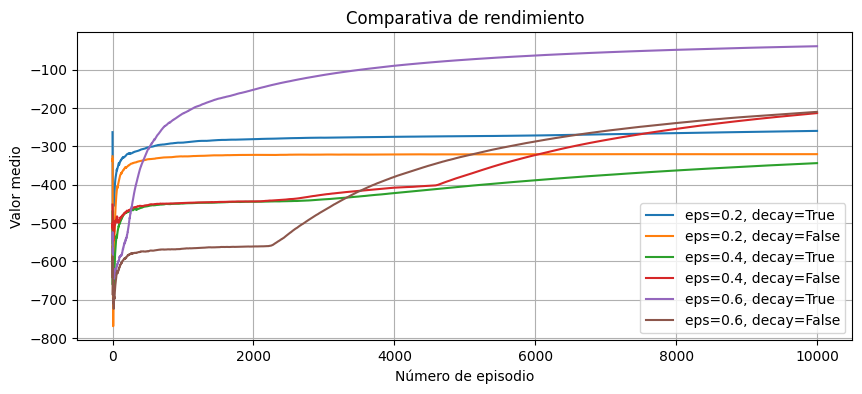

In [19]:
draw_multiple_learning_curves(dict_stats)

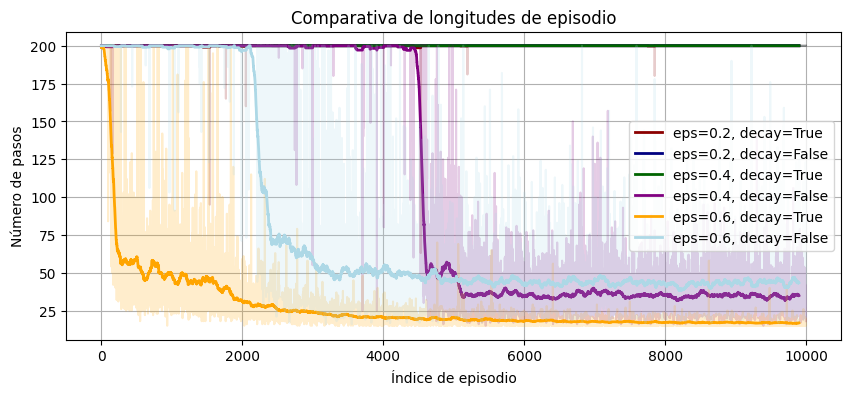

In [20]:
draw_episode_length_comparison(dict_len)

Las gráficas de reward medio y longitudes de los episodios obtenidas para el entorno Taxi-v3 mediante Monte Carlo On-Policy muestran con claridad el impacto del valor de $\epsilon$ y del uso de *decay* en el equilibrio exploración–explotación. En términos generales, la longitud de los episodios disminuye progresivamente cuando el agente comienza a identificar trayectorias más eficientes, lo que se traduce también en una mejora sostenida del reward medio. Este comportamiento es coherente con la dinámica del entorno, donde las penalizaciones por paso hacen que políticas más eficientes generen episodios más cortos y, por tanto, mayores recompensas acumuladas.

Cuando se emplea *decay*, el aprendizaje resulta significativamente más estable y eficiente. En particular, valores altos de $\epsilon$ combinados con reducción progresiva permiten una fase inicial de exploración intensa seguida de una consolidación hacia comportamientos más explotadores, lo que explica la mejora pronunciada tanto en la reducción de pasos como en el incremento del reward medio. En cambio, cuando $\epsilon$ se mantiene constante, la exploración permanente introduce una variabilidad considerable en la longitud de los episodios y limita la convergencia del rendimiento, ya que el agente continúa tomando acciones subóptimas incluso en fases avanzadas del entrenamiento.

Asimismo, valores bajos de $\epsilon$ favorecen una convergencia más rápida en términos de estabilidad, pero pueden ralentizar la mejora inicial si la exploración resulta insuficiente para descubrir trayectorias óptimas. Por el contrario, valores más altos sin *decay* mantienen episodios más largos y recompensas medias inferiores debido a la persistencia de decisiones aleatorias. En los resultados obtenidos, las configuraciones que muestran mejor comportamiento global son $\epsilon$ = 0.6 tanto con *decay* como sin él, y $\epsilon$ = 0.4 sin *decay*, ya que logran reducir de forma clara la longitud de los episodios y mejorar significativamente el reward medio. En cambio, el resto de configuraciones apenas consiguen que los episodios bajen del límite de 200 pasos, lo que indica que el agente no está encontrando políticas realmente eficientes. Es probable que en estos casos el aprendizaje se limite a evitar penalizaciones graves, como las acciones incorrectas de recogida o entrega de pasajeros (−10), sin llegar a optimizar la planificación completa de la ruta. Por el contrario, las configuraciones con mayor rendimiento parecen beneficiarse de una exploración más amplia, lo que les permite descubrir secuencias de acciones más eficientes y consolidarlas progresivamente.

En conjunto, los resultados reflejan el compromiso inherente entre exploración y explotación en métodos on-policy y evidencian que una estrategia de exploración decreciente resulta especialmente adecuada para un entorno como Taxi-v3, donde la estructura del problema recompensa políticas progresivamente más deterministas.

Ahora vamos a visualizar la política aprendida, usando las funciones auxiliares que muestran visualmente la política y generan gifs con el comportamiento del agente.


El entorno Taxi-v3 define el estado como una tupla de cuatro componentes:

\[
(row, col, passenger\_idx, destination\_idx)
\]

Esto implica que el espacio de estados es de dimensión 4, por lo que no es posible representar directamente la política completa en un mapa bidimensional.

Para poder visualizar el comportamiento aprendido por el agente, se fija la posición del pasajero y el destino, representando únicamente la política asociada a esa sección concreta del espacio de estados. De esta forma, se construye un mapa 5×5 que muestra la acción greedy seleccionada por el agente para cada posición del taxi bajo esas condiciones fijas.

Es importante destacar que esta representación no muestra la política global del agente, sino una proyección bidimensional condicionada a un estado específico del pasajero y del destino.

En particular, cuando el pasajero aún no ha sido recogido, la política visualizada refleja el comportamiento del agente orientado a desplazarse hacia la posición del pasajero. Una vez el pasajero es recogido, el estado cambia (el índice del pasajero pasa a indicar que está dentro del taxi), y por tanto la política relevante pertenece a otra sección distinta del espacio de estados, que no está incluida en esta visualización.

Por tanto, las tablas presentadas deben interpretarse como cortes del espacio de estados que permiten analizar de forma estructurada el comportamiento aprendido en cada fase de la tarea (búsqueda del pasajero y transporte hacia el destino).

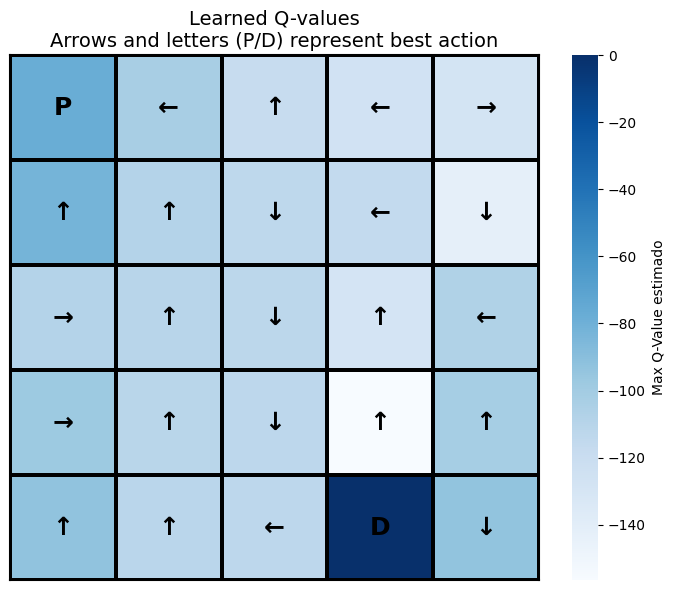

In [21]:

plot_taxi_q_values_map(agent_02_decay.get_q_values(), env)

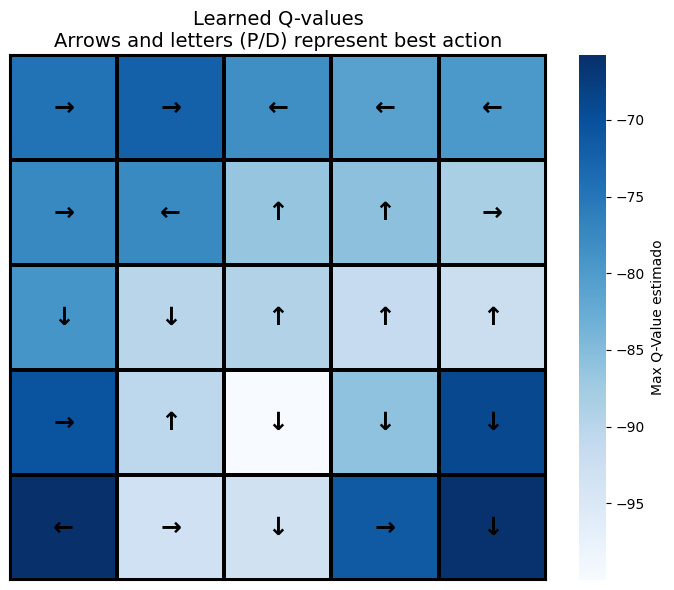

In [22]:
plot_taxi_q_values_map(agent_02_nodecay.get_q_values(), env)

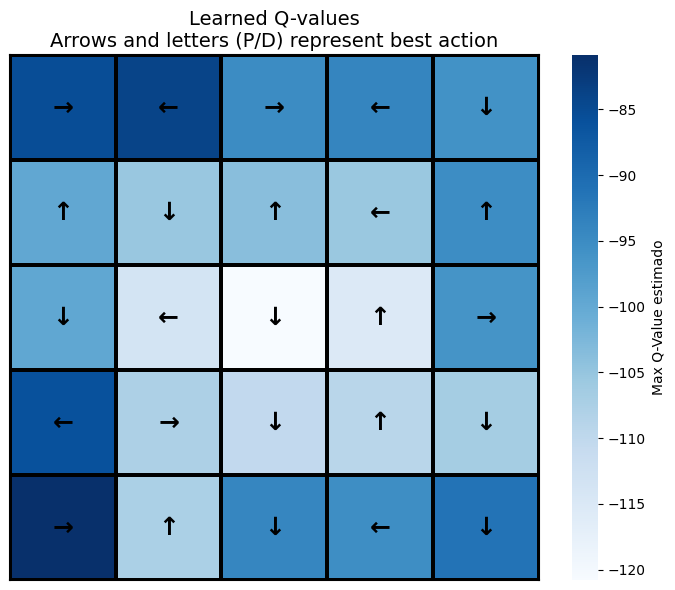

In [23]:
plot_taxi_q_values_map(agent_04_decay.get_q_values(), env)

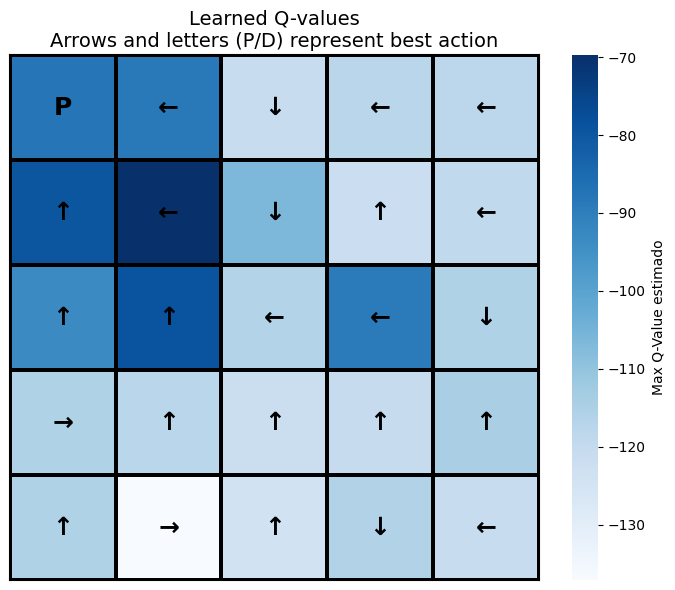

In [24]:
plot_taxi_q_values_map(agent_04_nodecay.get_q_values(), env)

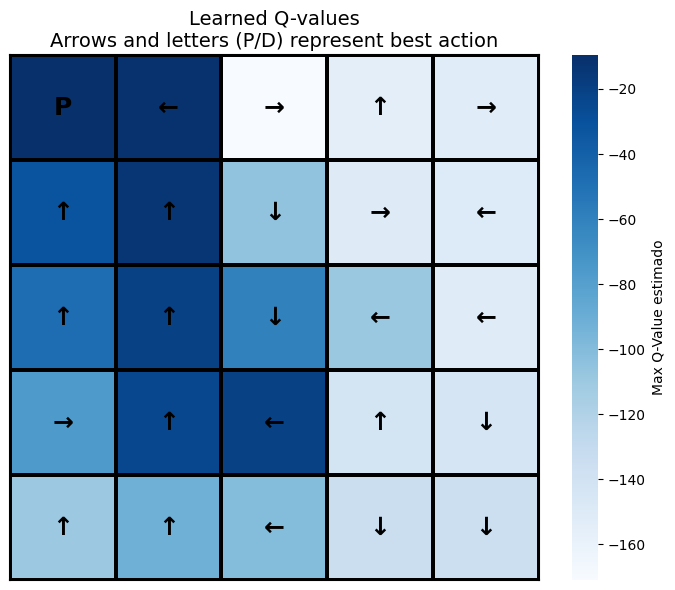

In [25]:
plot_taxi_q_values_map(agent_06_decay.get_q_values(), env)

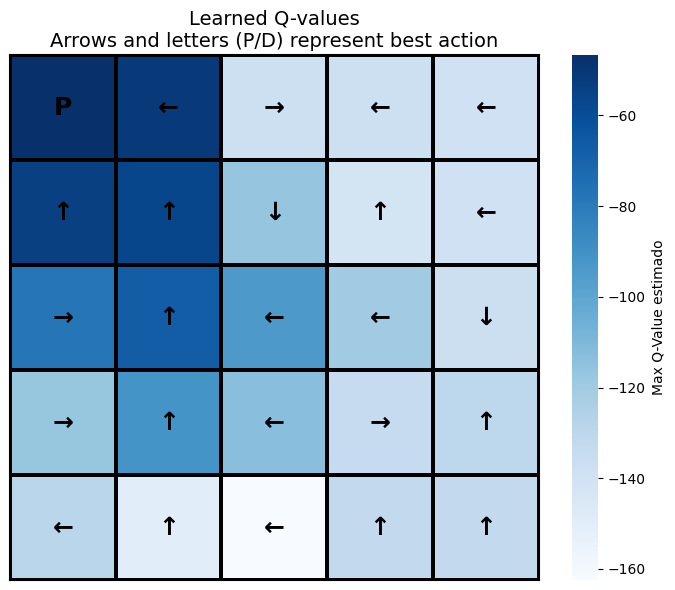

In [26]:
plot_taxi_q_values_map(agent_06_nodecay.get_q_values(), env)

Vemos cómo mostrar estos gráficos visuales es interesante pero no proporciona excesiva información. En general, se observa que las opciones que mejor rendimiento mostraron antes siguen mostrando valores de Q más consistentes en estos gráficos. Por ejemplo, el agente con epsilon 0.6 con decay muestra claramente que ha aprendido a recoger al paciente, ya que las acciones muestran que intentan llegar a su posición y luego recogerlo. Esto no estan claro en los agentes que mostraron peor rendimiento en las gráficas anteriores. Por ejemplo, el agente con epsilon 0.4 con decay no muestra un grid de acciones que refleje claramente que haya aprendido, lo que va en concordancia con su mal rendimeinto en las gráficas anteriores.

Debido a todo esto, vamos a generar un gif con el comportameinto de la política obtenida en el mejor caso, epsilon 0.6 con decay.

In [ ]:
# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
reward, len_episode, frames = capture_optimal_behavior(agent_06_decay)

# Crear el GIF a partir de los fotogramas capturados.
path = create_gif_from_frames(frames, "MCP_Tv3.gif")
print("Guardado en:", path)

show_gif_in_notebook(path)

Ahora vamos a dejar el epsilon fijo, dejándolo en 0.6 debido a que fue el agente que mejor resultado obtuvo, y con decay activado. Vamos entonces a variar el otro parámetro, el gamma (factor de descuento).

El objetivo de este experimento es estudiar cómo afecta la consideración de recompensas futuras al proceso de aprendizaje. Recordemos que este parámetro controla el peso relativo entre recompensas inmediatas y recompensas a largo plazo:

- Valores bajos de gamma favorecen estrategias más miopes, priorizando recompensas cercanas.
- Valores altos de gamma fomentan políticas más planificadas, al dar mayor importancia a recompensas futuras.

Este análisis permite comprender hasta qué punto el rendimiento del agente depende del horizonte temporal considerado durante la actualización de los valores Q.

Definimos los agentes con gamma 0.9 y 0.95 (el de 0.99 ya lo teníamos antes) y ejecutamos los entrenamientos.

In [27]:
agent_06_decay2 = MonteCarloOnPolicyAgent(env, epsilon=0.6, use_decay=True, gamma=0.9)
agent_06_decay3 = MonteCarloOnPolicyAgent(env, epsilon=0.6, use_decay=True, gamma=0.95)


In [28]:
list_len8, list_stats8 = on_policy_all_visit(agent_06_decay2, n_episodes)

 10%|█         | 1015/10000 [00:11<01:34, 94.81it/s]

success: -454.179, epsilon: 0.6


 20%|██        | 2014/10000 [00:22<01:15, 106.03it/s]

success: -440.7805, epsilon: 0.49975012493753124


 30%|███       | 3017/10000 [00:33<01:08, 102.03it/s]

...

 80%|████████  | 8016/10000 [01:28<00:22, 90.06it/s]

success: -317.84175, epsilon: 0.1249843769528809


 90%|█████████ | 9017/10000 [01:40<00:10, 90.22it/s]

success: -308.83033333333333, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [01:51<00:00, 90.01it/s]


In [29]:
list_len9, list_stats9 = on_policy_all_visit(agent_06_decay3, n_episodes)

 10%|█         | 1043/10000 [00:03<00:22, 404.63it/s]

success: -143.139, epsilon: 0.6


 21%|██        | 2078/10000 [00:06<00:14, 542.37it/s]

success: -113.064, epsilon: 0.49975012493753124


 31%|███       | 3085/10000 [00:07<00:09, 709.30it/s]

...

 81%|████████  | 8115/10000 [00:13<00:02, 795.08it/s]

success: -38.103875, epsilon: 0.1249843769528809


 92%|█████████▏| 9191/10000 [00:14<00:01, 796.30it/s]

success: -34.01533333333333, epsilon: 0.11109876680368848


100%|██████████| 10000/10000 [00:15<00:00, 639.03it/s]


Vamos a ver los resultados.

In [30]:
dict_stats3 = {'gamma=0.9': list_stats8, 'gamma=0.95': list_stats9, 'gamma=0.99': list_stats5}
dict_len3 = {'gamma=0.9': list_len8, 'gamma=0.95': list_len9, 'gamma=0.99': list_len5}

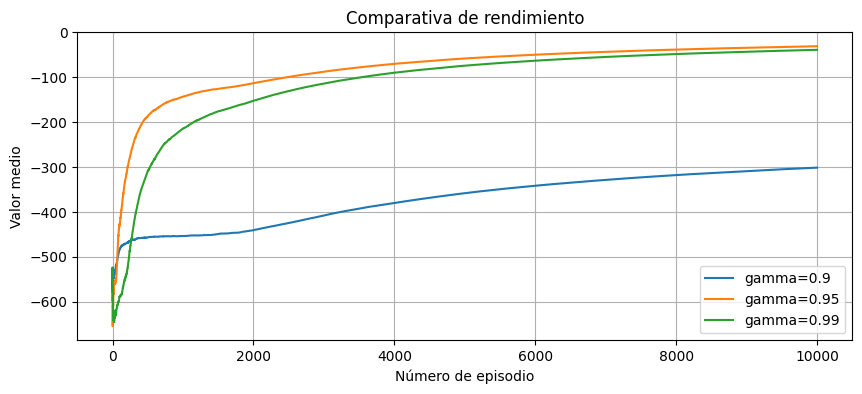

In [31]:
draw_multiple_learning_curves(dict_stats3)

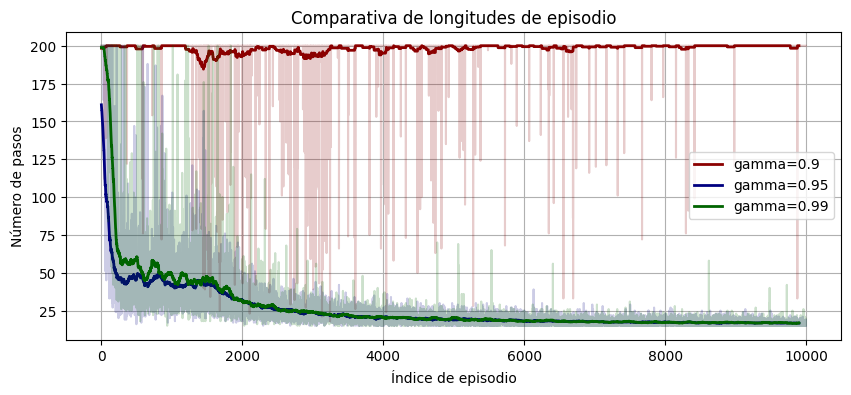

In [32]:
draw_episode_length_comparison(dict_len3)

Al fijar $\epsilon$ = 0.6 con *decay* y variar únicamente el factor de descuento $\gamma$, se observa que las tres configuraciones presentan una tendencia creciente del reward medio a medida que avanzan los episodios, lo que indica que el agente consigue mejorar progresivamente su política en todos los casos. No obstante, $\gamma$ = 0.95 muestra una ligera ventaja sobre $\gamma$ = 0.99 y una mejora más clara frente a $\gamma$ = 0.9.

Esta pequeña superioridad inicial de γ = 0.95 parece estar influida por las condiciones tempranas del entrenamiento. En las primeras iteraciones, la curva parte de valores menos negativos, lo que sugiere que los episodios iniciales fueron algo más cortos o menos penalizados, posiblemente debido a variaciones aleatorias propias del proceso exploratorio. Dado que el reward medio es acumulativo, un comienzo más favorable puede arrastrar una ligera ventaja en la curva durante buena parte del entrenamiento.

Desde el punto de vista teórico, valores altos de $\gamma$ (como 0.99) dan mayor peso a recompensas futuras, lo que en un entorno como Taxi-v3 debería ser beneficioso, ya que la recompensa positiva se obtiene al completar correctamente la tarea tras varias acciones intermedias. Sin embargo, un $\gamma$ ligeramente menor como 0.95 puede equilibrar mejor la propagación del retorno en fases tempranas, reduciendo la varianza del estimador y facilitando una estabilización algo más rápida. En cambio, $\gamma$ = 0.9 penaliza en exceso las recompensas lejanas, dificultando la valoración adecuada de trayectorias largas y explicando su peor rendimiento relativo.

En conjunto, las diferencias no son drásticas, lo que sugiere que el comportamiento global está más condicionado por la estrategia de exploración que por pequeñas variaciones en el factor de descuento, siendo la ventaja observada para $\gamma$ = 0.95 probablemente el resultado de una combinación entre menor varianza inicial y cierto efecto aleatorio en los primeros episodios.

## Entorno Frozen Lake 4x4

Tras analizar los resultados obtenidos en el entorno Taxi-v3, se observa que, aunque el agente logra cierta mejora progresiva, la convergencia es lenta y el rendimiento final no resulta especialmente satisfactorio. Esto es coherente con la complejidad del entorno, que presenta un espacio de estados relativamente grande, múltiples penalizaciones intermedias y una estructura de recompensas que exige secuencias largas y coherentes de acciones para alcanzar el objetivo. En este contexto, los métodos Monte Carlo pueden verse especialmente afectados por la alta varianza de los retornos y la necesidad de completar episodios enteros antes de actualizar la función de valor. En este sentido, métodos basados en *Diferencias Temporales*, como SARSA o Q-Learning, suelen mostrar mejores resultados en este tipo de entornos, ya que actualizan los valores de forma incremental en cada paso, reduciendo la varianza de las estimaciones y propagando la información de recompensa de manera más eficiente a lo largo del episodio.

Por este motivo, resulta razonable contrastar el comportamiento del agente en un entorno más sencillo como Frozen Lake 4x4 no resbaladizo. Este entorno presenta un espacio de estados mucho más reducido y una dinámica más simple, lo que permite analizar con mayor claridad la capacidad del algoritmo para aprender una política adecuada sin que la complejidad estructural del problema enmascare los resultados. Además, al tratarse de un escenario clásico en aprendizaje por refuerzo, facilita la comparación cualitativa del proceso de convergencia y la interpretación de las políticas aprendidas.

Creamos el entorno y el agente, y ejecutamos el aprendizaje.

In [ ]:
env2 = gym.make('FrozenLake-v1', is_slippery=False, map_name="4x4", render_mode="rgb_array", max_episode_steps=100)

agent_02_decay2 = MonteCarloOnPolicyAgent(env2, epsilon=0.2, use_decay=True, gamma=0.99)
agent_02_nodecay2 = MonteCarloOnPolicyAgent(env2, epsilon=0.2, use_decay=False, gamma=0.99)
agent_04_decay2 = MonteCarloOnPolicyAgent(env2, epsilon=0.4, use_decay=True, gamma=0.99)
agent_04_nodecay2 = MonteCarloOnPolicyAgent(env2, epsilon=0.4, use_decay=False, gamma=0.99)
agent_06_decay4 = MonteCarloOnPolicyAgent(env2, epsilon=0.6, use_decay=True, gamma=0.99)
agent_06_nodecay2 = MonteCarloOnPolicyAgent(env2, epsilon=0.6, use_decay=False, gamma=0.99)


In [ ]:
n_episodes = 50000

list_len10, list_stats10 = on_policy_all_visit(agent_02_decay2, n_episodes)

 10%|█         | 5061/50000 [00:14<02:09, 346.53it/s]

success: 0.0, epsilon: 0.19996000799840033


 20%|██        | 10024/50000 [00:33<03:50, 173.39it/s]

success: 0.0, epsilon: 0.0999900009999


 30%|███       | 15027/50000 [00:57<03:05, 188.51it/s]

...

 80%|████████  | 40032/50000 [03:25<00:57, 174.41it/s]

success: 0.0, epsilon: 0.02499937501562461


 90%|█████████ | 45030/50000 [03:55<00:29, 167.63it/s]

success: 0.0, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [04:26<00:00, 187.73it/s]


In [ ]:
list_len11, list_stats11 = on_policy_all_visit(agent_02_nodecay2, n_episodes)

 10%|█         | 5130/50000 [00:07<01:01, 727.16it/s]

success: 0.5424, epsilon: 0.2


 20%|██        | 10157/50000 [00:13<00:39, 1008.40it/s]

success: 0.6639, epsilon: 0.2


 30%|███       | 15120/50000 [00:18<00:33, 1029.84it/s]

...

 80%|████████  | 40244/50000 [00:42<00:04, 2294.51it/s]

success: 0.753925, epsilon: 0.2


 91%|█████████ | 45327/50000 [00:44<00:02, 2231.86it/s]

success: 0.7563111111111112, epsilon: 0.2


100%|██████████| 50000/50000 [00:47<00:00, 1047.95it/s]


In [ ]:
list_len12, list_stats12 = on_policy_all_visit(agent_04_decay2, n_episodes)

 11%|█         | 5275/50000 [00:03<00:20, 2225.13it/s]

success: 0.519, epsilon: 0.19996000799840033


 21%|██        | 10417/50000 [00:05<00:16, 2341.87it/s]

success: 0.6858, epsilon: 0.0999900009999


 31%|███       | 15479/50000 [00:07<00:14, 2374.86it/s]

...

 81%|████████  | 40423/50000 [00:19<00:04, 2342.46it/s]

success: 0.8863, epsilon: 0.02499937501562461


 91%|█████████ | 45415/50000 [00:21<00:02, 2246.52it/s]

success: 0.8959333333333334, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:24<00:00, 2066.59it/s]


In [ ]:
list_len13, list_stats13 = on_policy_all_visit(agent_04_nodecay2, n_episodes)

 10%|█         | 5229/50000 [00:04<00:21, 2075.62it/s]

success: 0.4578, epsilon: 0.4


 21%|██        | 10364/50000 [00:06<00:17, 2253.62it/s]

success: 0.4935, epsilon: 0.4


 30%|███       | 15245/50000 [00:09<00:15, 2225.04it/s]

...

 81%|████████  | 40404/50000 [00:29<00:04, 2042.22it/s]

success: 0.53155, epsilon: 0.4


 91%|█████████ | 45431/50000 [00:32<00:02, 2076.84it/s]

success: 0.5334222222222222, epsilon: 0.4


100%|██████████| 50000/50000 [00:35<00:00, 1404.26it/s]


In [ ]:
list_len14, list_stats14 = on_policy_all_visit(agent_06_decay4, n_episodes)

 11%|█         | 5308/50000 [00:02<00:28, 1583.07it/s]

success: 0.483, epsilon: 0.19996000799840033


 21%|██        | 10341/50000 [00:06<00:18, 2196.76it/s]

success: 0.6663, epsilon: 0.0999900009999


 30%|███       | 15241/50000 [00:09<00:27, 1279.95it/s]

...

 81%|████████  | 40257/50000 [00:22<00:04, 2353.59it/s]

success: 0.880925, epsilon: 0.02499937501562461


 91%|█████████ | 45322/50000 [00:24<00:02, 2334.93it/s]

success: 0.8916444444444445, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:26<00:00, 1867.88it/s]


In [ ]:
list_len15, list_stats15 = on_policy_all_visit(agent_06_nodecay2, n_episodes)

 10%|█         | 5195/50000 [00:04<00:33, 1329.15it/s]

success: 0.262, epsilon: 0.6


 21%|██        | 10417/50000 [00:07<00:19, 2052.59it/s]

success: 0.2772, epsilon: 0.6


 30%|███       | 15214/50000 [00:09<00:17, 2044.48it/s]

...

 81%|████████  | 40404/50000 [00:22<00:04, 2106.62it/s]

success: 0.29165, epsilon: 0.6


 91%|█████████ | 45355/50000 [00:25<00:02, 1956.34it/s]

success: 0.29084444444444446, epsilon: 0.6


100%|██████████| 50000/50000 [00:27<00:00, 1822.13it/s]


Vamos a ver los resultados.

In [ ]:
dict_stats2 = {'eps=0.2, decay=True': list_stats10, 'eps=0.2, decay=False': list_stats11, 'eps=0.4, decay=True': list_stats12, 'eps=0.4, decay=False': list_stats13, 'eps=0.6, decay=True': list_stats14, 'eps=0.6, decay=False': list_stats15}
dict_len2 = {'eps=0.2, decay=True': list_len10, 'eps=0.2, decay=False': list_len11, 'eps=0.4, decay=True': list_len12, 'eps=0.4, decay=False': list_len13, 'eps=0.6, decay=True': list_len14, 'eps=0.6, decay=False': list_len15}

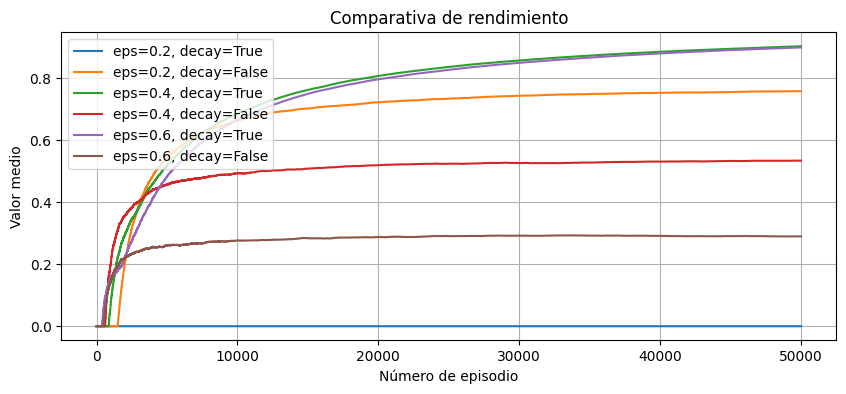

In [ ]:
draw_multiple_learning_curves(dict_stats2)

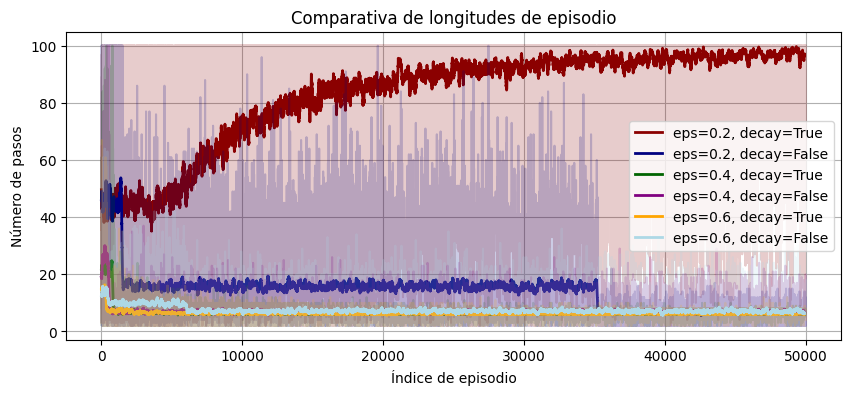

In [ ]:
draw_episode_length_comparison(dict_len2)

Las gráficas obtenidas para el entorno **FrozenLake** mediante Monte Carlo On-Policy muestran un un mejor rendimiento que el observado previamente en Taxi-v3, algo esperable dado que se trata de un entorno considerablemente más sencillo y con un espacio de estados y transiciones menos complejo. En este caso, la longitud de los episodios y el valor medio convergen de forma más definida, permitiendo apreciar con mayor nitidez el efecto del parámetro $\epsilon$ y del uso de *decay*.

En la gráfica de longitud de episodios se observa que, cuando se emplea *decay*, especialmente con valores de $\epsilon$ = 0.4 y $\epsilon$ = 0.6, los episodios tienden progresivamente a estabilizarse en longitudes cortas (en torno a 5–10 pasos). Este comportamiento indica que el agente logra identificar trayectorias eficientes hacia el objetivo y consolidarlas con el tiempo. La fase inicial presenta mayor variabilidad debido a la exploración intensa, pero a medida que $\epsilon$ disminuye, la política se vuelve más determinista y los episodios reducen tanto su media como su dispersión.

La gráfica de rendimiento medio refuerza esta interpretación. Las configuraciones con *decay* y $\epsilon$ intermedio–alto (0.4 y 0.6) alcanzan los valores medios más elevados (aproximadamente 0.85–0.9), mostrando una mejora sostenida a lo largo de los episodios. Esto sugiere que una exploración inicial amplia resulta clave para descubrir la ruta óptima en FrozenLake, pero que la reducción progresiva de $\epsilon$ es fundamental para consolidar dicha política y evitar degradaciones posteriores.

En cambio, los valores constantes de $\epsilon$ limitan el rendimiento máximo alcanzado. Aunque pueden mostrar una mejora inicial relativamente rápida, su convergencia es menor y se estabilizan en valores medios inferiores. Esto evidencia que la exploración permanente introduce ruido suficiente como para impedir una explotación plena de la política aprendida.

Un caso particular es $\epsilon$ = 0.2 con *decay*, que muestra un rendimiento prácticamente nulo. Este resultado sugiere que una exploración inicial demasiado limitada puede impedir que el agente descubra trayectorias exitosas en un entorno estocástico como FrozenLake. Si el agente no explora lo suficiente al principio, puede quedar atrapado en políticas subóptimas sin alcanzar con frecuencia el estado objetivo, lo que impide mejorar el valor estimado.

En conjunto, los resultados reflejan de forma clara el compromiso exploración–explotación característico de los métodos on-policy. En un entorno más simple como FrozenLake, la estrategia de *decay* demuestra ser especialmente efectiva permitiendo una exploración suficiente en etapas tempranas y favoreciendo posteriormente una convergencia estable hacia políticas casi deterministas.

## Posibles mejoras y líneas de Investigación Futuras

**Variaciones en el decaimiento de epsilon:** Se ha utilizado un esquema inversamente proporcional para el decaimiento de epsilon, pero se podría estudiar la influencia de otros métodos de decaimiento. Se ha observado que en algunos casos el decaimiento provocaba que la exploración no fuera suficiente y el rendimiento del agente no llegase a ser bueno. Probar con otros esquemas de decaimiento sería interesante.

**Análisis más profundo del factor de descuento gamma:** En este trabajo se han probado distintos valores de gamma para un epsilon seleccionado, pero se podrían explorar combinaciones adicionales para entender mejor la interacción entre la planificación a largo plazo y la exploración inicial.

**Aumento del número de episodios y análisis estadístico:** Aunque 10000 episodios para Taxi-v3 y 50000 para Frozen Lake permiten observar tendencias claras, ampliar el número de episodios podría ayudar a verificar la convergencia real de las políticas. Además, repetir cada configuración varias veces con distintas semillas aleatorias permitiría realizar un análisis estadístico más riguroso (media y desviación estándar del rendimiento), reduciendo el impacto de la estocasticidad del entorno.

**Exploración de estrategias alternativas de exploración:** Más allá de la política $\epsilon$-greedy, podrían evaluarse enfoques como softmax o métodos basados en incertidumbre. Estas estrategias podrían proporcionar un equilibrio exploración–explotación más eficiente, especialmente en fases tempranas del entrenamiento donde la información disponible es limitada.
